# Exercise 2

In [1]:
using LinearAlgebra, Statistics, MAT, Plots

include("bidiag2.jl")
include("TregsRLooCV.jl")

TregsRLooCV (generic function with 1 method)

In [2]:
data = matread("FTIR_AMW_MLA310.mat")
CL1 = Int.(vec(data["CL1"]))

X = data["X"]
y = vec(data["y"])

885-element Vector{Float64}:
 3393.8
 3227.95
 2957.1
 2845.5
 2719.45
 2764.5
 2466.05
 2285.6
 2201.4
 2083.9
    ⋮
 2339.0
 2236.0
 1964.0
 1880.0
 1560.0
 1355.0
 1308.0
 1232.0
 1085.0

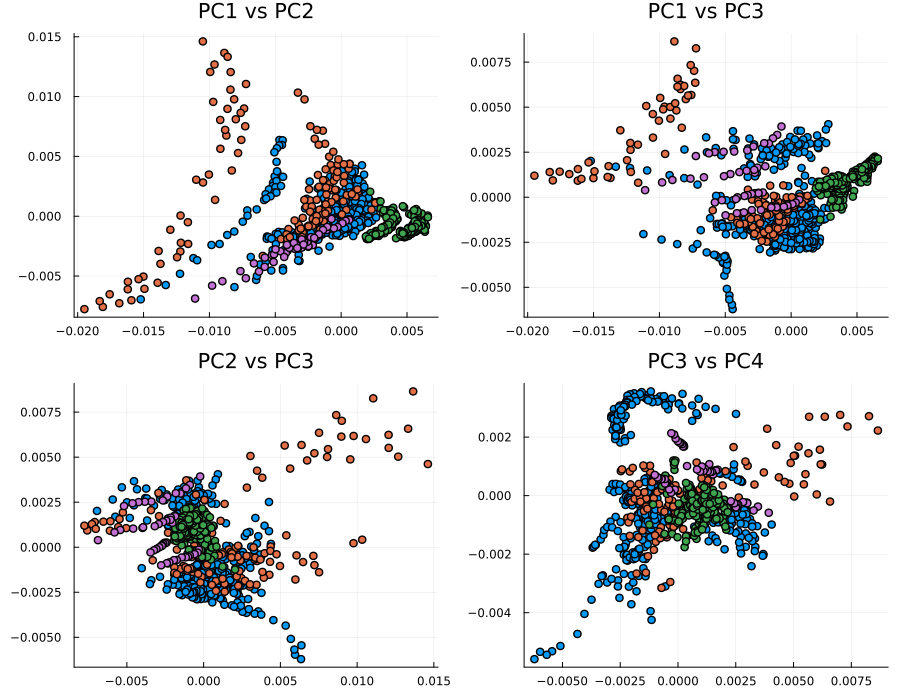

In [18]:
# We perform PCA to explore whether species form distinct clusters.
Xc = X .- mean(X, dims=1)
U, S, V = svd(Xc)
T = U * Diagonal(S)

pairs = [(1,2), (1,3), (2,3), (3,4)]

plots = []

for (i,j) in pairs
    p = scatter(T[:,i], T[:,j],
        group = CL1,
        title = "PC$i vs PC$j",
        legend = false)
    
    push!(plots, p)
end

plot(plots..., layout = (2,2), size = (900, 700))

The PCA plots show that there is some grouping of the samples according to species, but the separation is not very clear. In the plots of PC1 vs PC2 and PC1 vs PC3, some clusters can be seen, which indicates that the data contains information related to the different species. However, there is still a lot of overlap between the groups.

In the plots involving higher components, such as PC2 vs PC3 and PC3 vs PC4, the separation becomes even less clear, and the points are more mixed. This suggests that the first principal components capture most of the structure in the data, while the later components mostly contain smaller variations or noise.

Overall, PCA shows that there are some patterns related to species, but it is not enough to clearly separate them. Therefore, more advanced methods like PLS regression are needed to better model the relationship between the data and the response variable.

In [4]:
# PLS modell
β₀, β, Tpls, B, W, q = bidiag2(X, y, mc=50)

y_pred = X * β[:,end] .+ β₀[end]

rms_global = sqrt(mean((y - y_pred).^2))
println("Global PLS RMS: ", rms_global)

Global PLS RMS: 330.0880606288656


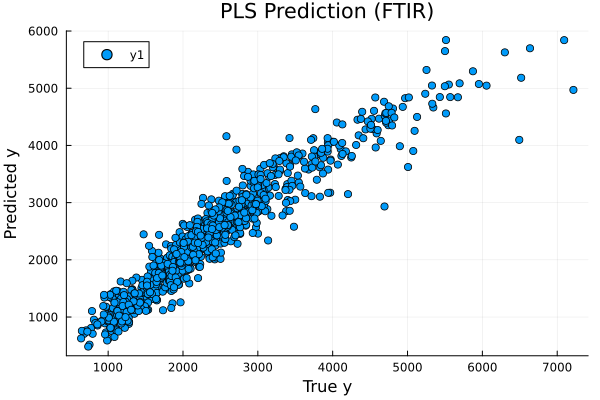

In [5]:
# plot
scatter(y, y_pred, xlabel="True y", ylabel="Predicted y", title="PLS Prediction (FTIR)")

In [6]:
function loocv_pls(X, y; mc=50)
    m = size(X,1)
    preds = zeros(m)

    for i in 1:m
        idx = setdiff(1:m, [i])

        β₀, β, _, _, _, _ = bidiag2(X[idx,:], y[idx]; mc=mc)

        preds[i] = X[i,:]' * β[:,end] + β₀[end]
    end

    return sqrt(mean((y - preds).^2))
end

println("PLS LOO-CV RMS: ", loocv_pls(X, y))

PLS LOO-CV RMS: 479.213084700884


In [7]:
for c in unique(CL1)
    idx = findall(CL1 .== c)

    β₀, β, _, _, _, _ = bidiag2(X[idx,:], y[idx]; mc=50)

    y_pred = X[idx,:] * β[:,end] .+ β₀[end]

    rms = sqrt(mean((y[idx] - y_pred).^2))
    println("Class $c RMS: ", rms)
end

Class 1 RMS: 151.7302437313621
Class 2 RMS: 63.90789878747983
Class 3 RMS: 87.90866881386533
Class 4 RMS: 1.7452302461033637e-12


In [8]:
preds_all = zeros(length(y))

for c in unique(CL1)
    idx = findall(CL1 .== c)

    β₀, β, _, _, _, _ = bidiag2(X[idx,:], y[idx]; mc=50)

    preds_all[idx] = X[idx,:] * β[:,end] .+ β₀[end]
end

println("Combined local RMS: ", sqrt(mean((y - preds_all).^2)))

Combined local RMS: 118.59324825034527


In [9]:
# CV ridge

λs = 10 .^ range(-5, 5, length=50)

press, minid, U, σ, V, H, bcoefs, λ, bλ, hλ = TregsRLooCV(X, y, λs)

println("Best lambda: ", λ)

Best lambda: 1.0e-5


In [10]:
function loocv_pls_subset(X, y; mc=50)
    m = size(X,1)
    preds = zeros(m)

    for i in 1:m
        idx = setdiff(1:m, [i])
        β₀, β, _, _, _, _ = bidiag2(X[idx,:], y[idx]; mc=mc)
        preds[i] = X[i,:]' * β[:,end] + β₀[end]
    end

    return sqrt(mean((y - preds).^2))
end

loocv_pls_subset (generic function with 1 method)

In [11]:
for c in unique(CL1)
    idx = findall(CL1 .== c)
    rms = loocv_pls_subset(X[idx,:], y[idx])
    println("Class $c LOO RMS: ", rms)
end

Class 1 LOO RMS: 340.51310212099406
Class 2 LOO RMS: 1039.0140038427242
Class 3 LOO RMS: 403.1753659820329
Class 4 LOO RMS: 103.83426182365581


The global PLS model uses all the data to build a single model, while the local models are trained separately for each species. The results show that the local models often give lower RMS errors for their own class, since they are more specialized. However, they use less data, which can make them less stable. The global model is more general and may perform better overall when predicting across all samples.

In [12]:
# MOLS
function weighted_ridge(X, y, weights, λ)
    W = Diagonal(weights)
    β = inv(X' * W * X + λ * I) * (X' * W * y)
    return β
end

λ = 0.1

for c in unique(CL1)
    weights = ones(length(y))
    weights[CL1 .!= c] .= 0.2

    β = weighted_ridge(X, y, weights, λ)

    y_pred = X * β
    println("MOLS class $c RMS: ", sqrt(mean((y - y_pred).^2)))
end

MOLS class 1 RMS: 1497.3111999262692
MOLS class 2 RMS: 1668.3217491401263
MOLS class 3 RMS: 1496.916215211814
MOLS class 4 RMS: 1898.273224235293


PLS and ridge regression are both used to handle high-dimensional data. PLS reduces the data to a smaller number of components that are relevant for predicting the response, while ridge regression shrinks the coefficients to avoid overfitting. In this case, PLS often performs better because it takes into account the relationship between X and y, while ridge regression only regularizes the coefficients.

Similar to PLS, local ridge models are trained separately for each species and can give better performance for individual classes. However, the global ridge model uses all the data and may be more stable. The difference between global and local ridge models is usually smaller than for PLS.

The results show that PLS generally performs better than ridge regression for this type of data, since it captures the relationship between the predictors and the response more effectively. Local models can improve performance for individual species but may overfit due to smaller datasets. The MOLS approach provides a balance by using all data while focusing more on a specific class, which can improve prediction accuracy without losing stability.